# 05 · Preprocesamiento y reducción de dimensionalidad (Fase 3)
**Responsable:** Juan Pablo
**Objetivo:** dejar los datos listos para un futuro modelo: codificar variables categóricas, escalar variables numéricas y aplicar PCA para reducir la dimensionalidad y visualizar los datos.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # para poder importar src/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import (configurar_graficos, cargar_datos, guardar_figura,
                       VARIABLES_NUMERICAS, VARIABLES_CATEGORICAS, OBJETIVO,
                       RUTA_PROCESADOS)
configurar_graficos()
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
df = pd.read_csv(RUTA_PROCESADOS / "bank_limpio.csv")
print(df.shape)
df.head()

(41176, 22)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,contactado_antes
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0
1,53,technician,married,university.degree,no,no,no,cellular,nov,fri,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1,1


## 1. Selección de variables
- Se elimina **`duration`** porque produce fuga de información (solo se conoce después de la llamada).
- Se elimina **`pdays`** porque ya está representada por `contactado_antes`.

In [2]:
X = df.drop(columns=[OBJETIVO, "duration", "pdays"])
y = df[OBJETIVO]

num_sesgadas = ["campaign", "previous"]                         # log(1+x) + escalado
num_normales = ["age", "emp_var_rate", "cons_price_idx", "cons_conf_idx", "euribor3m", "nr_employed"]
binarias     = ["contactado_antes"]
ordinales    = ["education"]
nominales    = ["job", "marital", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]
print("Variables de entrada:", X.shape[1])

Variables de entrada: 19


## 2. Codificación y escalado
| Tipo | Técnica | Por qué |
|---|---|---|
| Nominales (job, month, …) | **One-Hot Encoding** | No tienen orden; cada categoría se vuelve una columna 0/1. |
| Ordinal (education) | **Ordinal Encoding** | Los niveles educativos sí tienen un orden natural. |
| Numéricas sesgadas (campaign, previous) | **log(1+x) + StandardScaler** | Reducir el sesgo visto en el notebook 03. |
| Numéricas restantes | **StandardScaler** (media 0, desv. 1) | PCA es sensible a la escala. |

In [3]:
orden_educ = [["illiterate", "basic.4y", "basic.6y", "basic.9y", "high.school",
               "professional.course", "university.degree"]]

preprocesador = ColumnTransformer([
    ("sesgadas", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")), ("esc", StandardScaler())]), num_sesgadas),
    ("numericas", StandardScaler(), num_normales),
    ("binarias", "passthrough", binarias),
    ("ordinal", Pipeline([("ord", OrdinalEncoder(categories=orden_educ)), ("esc", StandardScaler())]), ordinales),
    ("nominales", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominales),
])

X_prep = preprocesador.fit_transform(X)
columnas = preprocesador.get_feature_names_out()
X_prep = pd.DataFrame(X_prep, columns=columnas)
print(f"Antes: {X.shape[1]} columnas  ->  Después de codificar: {X_prep.shape[1]} columnas")
X_prep.head()

Antes: 19 columnas  ->  Después de codificar: 51 columnas


,sesgadas__campaign,sesgadas__previous,numericas__age,numericas__emp_var_rate,numericas__cons_price_idx,numericas__cons_conf_idx,numericas__euribor3m,numericas__nr_employed,binarias__contactado_antes,ordinal__education,...,nominales__month_oct,nominales__month_sep,nominales__day_of_week_fri,nominales__day_of_week_mon,nominales__day_of_week_thu,nominales__day_of_week_tue,nominales__day_of_week_wed,nominales__poutcome_failure,nominales__poutcome_nonexistent,nominales__poutcome_success
0,-0.883028,-0.381474,0.381573,0.839079,-0.227562,0.951394,0.773578,0.845186,0.0,-1.967163,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.883028,-0.381474,1.245251,-0.115810,-0.649100,-0.323509,0.230456,0.398131,0.0,1.070432,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.565598,3.499921,-1.153854,-1.134358,0.828013,0.151878,-1.667589,-2.428148,1.0,1.070432,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.035636,-0.381474,-0.098248,-1.198017,-0.865052,-1.425544,-1.277833,-0.940269,0.0,-0.144606,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.883028,2.067414,1.437179,-1.898269,-2.374990,1.966994,-1.586870,-1.257222,1.0,-1.967163,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [4]:
# Verificación del escalado: media ~0 y desviación ~1 en las numéricas
cols_num = [c for c in columnas if c.startswith(("sesgadas", "numericas", "ordinal"))]
X_prep[cols_num].describe().loc[["mean", "std"]].round(3)

,sesgadas__campaign,sesgadas__previous,numericas__age,numericas__emp_var_rate,numericas__cons_price_idx,numericas__cons_conf_idx,numericas__euribor3m,numericas__nr_employed,ordinal__education
mean,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


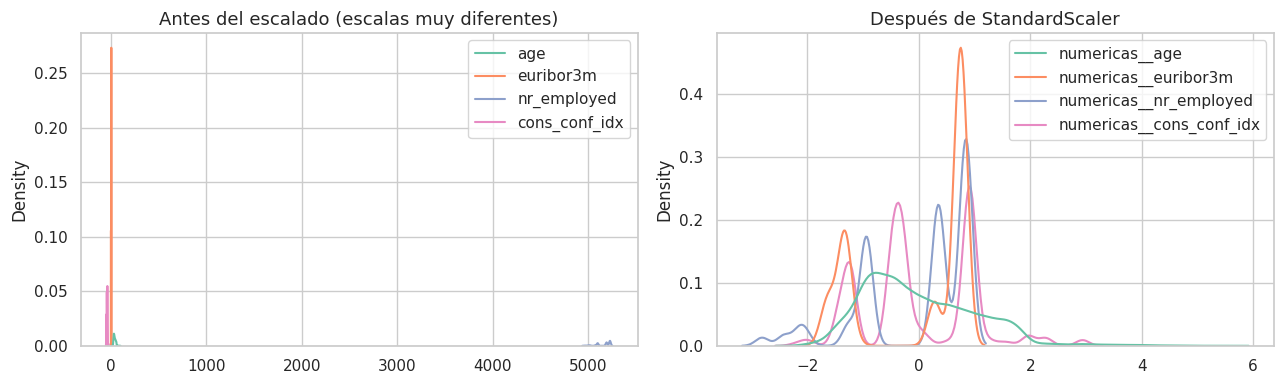

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.kdeplot(data=X[["age", "euribor3m", "nr_employed", "cons_conf_idx"]], ax=axes[0])
axes[0].set_title("Antes del escalado (escalas muy diferentes)")
sns.kdeplot(data=X_prep[["numericas__age", "numericas__euribor3m", "numericas__nr_employed", "numericas__cons_conf_idx"]], ax=axes[1])
axes[1].set_title("Después de StandardScaler")
plt.tight_layout()
guardar_figura("05_antes_despues_escalado")
plt.show()

## 3. Reducción de dimensionalidad con PCA

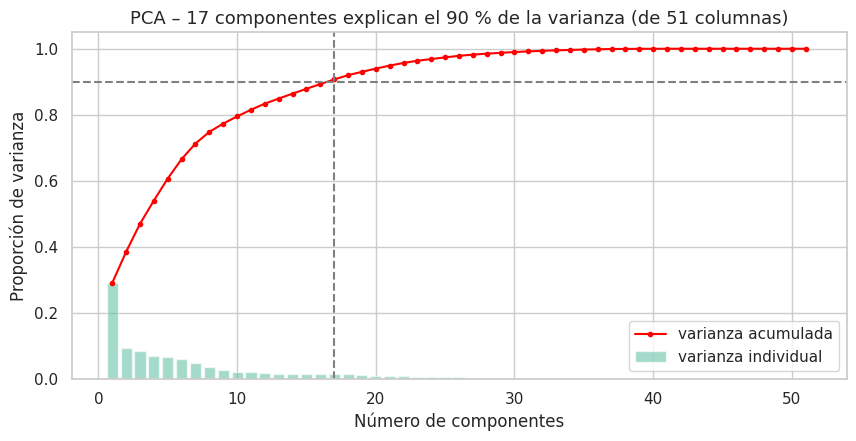

Componentes para 90 % de varianza: 17
Componentes para 95 % de varianza: 22
PC1 + PC2 explican: 38.5 %


In [6]:
pca_completo = PCA().fit(X_prep)
var_acum = np.cumsum(pca_completo.explained_variance_ratio_)
n_90 = np.argmax(var_acum >= 0.90) + 1
n_95 = np.argmax(var_acum >= 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(range(1, len(var_acum) + 1), pca_completo.explained_variance_ratio_, alpha=0.6, label="varianza individual")
ax.plot(range(1, len(var_acum) + 1), var_acum, marker="o", ms=3, color="red", label="varianza acumulada")
ax.axhline(0.90, ls="--", color="gray"); ax.axvline(n_90, ls="--", color="gray")
ax.set_xlabel("Número de componentes"); ax.set_ylabel("Proporción de varianza")
ax.set_title(f"PCA – {n_90} componentes explican el 90 % de la varianza (de {X_prep.shape[1]} columnas)")
ax.legend()
guardar_figura("05_pca_varianza")
plt.show()

print(f"Componentes para 90 % de varianza: {n_90}")
print(f"Componentes para 95 % de varianza: {n_95}")
print(f"PC1 + PC2 explican: {var_acum[1]*100:.1f} %")

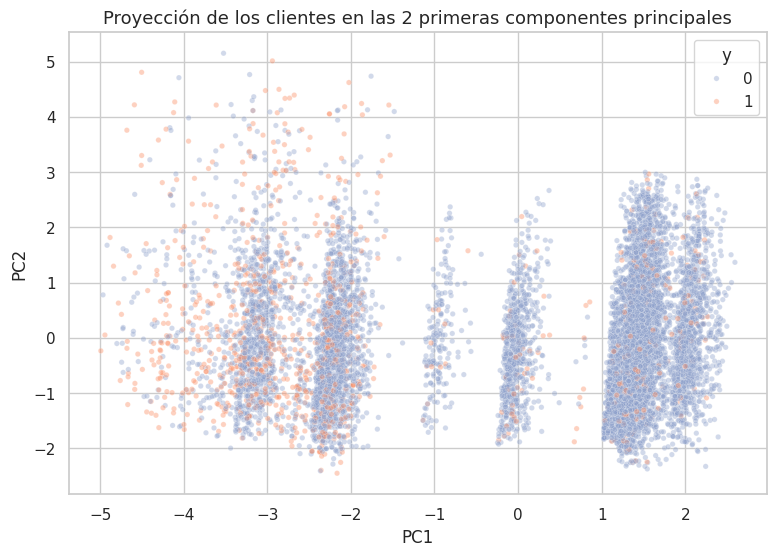

In [7]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_prep)
pca_df = pd.DataFrame(X_pca2, columns=["PC1", "PC2"]); pca_df["y"] = y.values

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df.sample(10000, random_state=3), x="PC1", y="PC2", hue="y",
                alpha=0.4, s=15, palette={0: "#8da0cb", 1: "#fc8d62"})
plt.title("Proyección de los clientes en las 2 primeras componentes principales")
guardar_figura("05_pca_2d")
plt.show()

In [8]:
# ¿Qué variables pesan más en cada componente? (cargas / loadings)
cargas = pd.DataFrame(pca2.components_.T, index=columnas, columns=["PC1", "PC2"])
top = pd.concat([cargas["PC1"].abs().nlargest(6), cargas["PC2"].abs().nlargest(6)], axis=1).fillna("")
print("Variables con mayor peso en PC1:"); print(cargas["PC1"].reindex(cargas["PC1"].abs().nlargest(6).index).round(3))
print("\nVariables con mayor peso en PC2:"); print(cargas["PC2"].reindex(cargas["PC2"].abs().nlargest(6).index).round(3))

Variables con mayor peso en PC1:
numericas__euribor3m            0.485
numericas__emp_var_rate         0.485
numericas__nr_employed          0.454
numericas__cons_price_idx       0.384
sesgadas__previous             -0.300
nominales__contact_telephone    0.118
Name: PC1, dtype: float64

Variables con mayor peso en PC2:
numericas__age                0.657
ordinal__education           -0.630
nominales__marital_single    -0.189
nominales__marital_married    0.169
nominales__job_blue-collar    0.126
numericas__cons_conf_idx      0.121
Name: PC2, dtype: float64


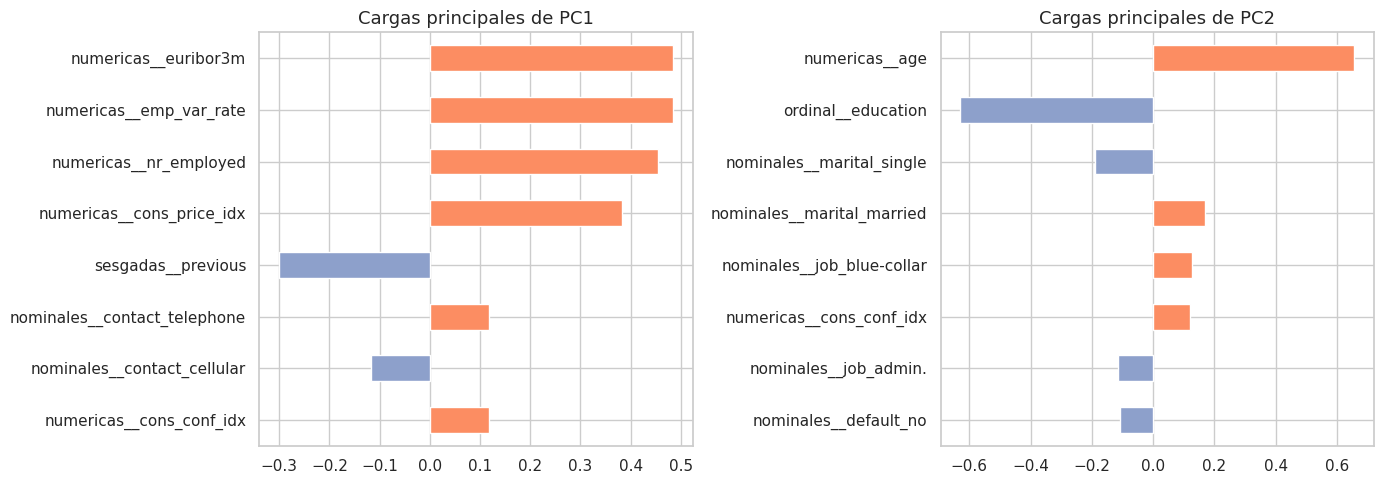

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for comp, ax in zip(["PC1", "PC2"], axes):
    s = cargas[comp].reindex(cargas[comp].abs().nlargest(8).index)
    s.plot(kind="barh", ax=ax, color=["#fc8d62" if v > 0 else "#8da0cb" for v in s])
    ax.invert_yaxis(); ax.set_title(f"Cargas principales de {comp}")
plt.tight_layout()
guardar_figura("05_pca_cargas")
plt.show()

In [10]:
# Guardar el dataset reducido (componentes que explican el 90 %)
pca_final = PCA(n_components=n_90, random_state=42)
X_pca = pd.DataFrame(pca_final.fit_transform(X_prep), columns=[f"PC{i+1}" for i in range(n_90)])
X_pca["y"] = y.values
X_prep.assign(y=y.values).to_csv(RUTA_PROCESADOS / "bank_preprocesado.csv", index=False)
X_pca.to_csv(RUTA_PROCESADOS / "bank_pca.csv", index=False)
print("Guardados: bank_preprocesado.csv", X_prep.shape, "| bank_pca.csv", X_pca.shape)

Guardados: bank_preprocesado.csv (41176, 51) | bank_pca.csv (41176, 18)


## 4. Conclusiones del preprocesamiento
1. Se eliminaron `duration` (fuga de información) y `pdays` (reemplazada por `contactado_antes`).
2. Con One-Hot, Ordinal Encoding y escalado, las 19 variables de entrada pasaron a ser **51 columnas numéricas**.
3. **PCA** explica el 90 % de la varianza con **17 componentes** (de 51 columnas, reducción de ≈67 %); PC1 + PC2 explican ≈38,5 %, lo que confirma que hay **información redundante** (por ejemplo, las variables macroeconómicas).
4. **PC1 está dominada por las variables macroeconómicas** (`euribor3m`, `nr_employed`, `emp_var_rate`): resume el *ciclo económico*. PC2 está dominada por edad (+) y educación (−) — el *perfil demográfico*. En el gráfico 2D los clientes que suscriben se concentran en los valores negativos de PC1, lo que coincide con el hallazgo de que suscriben más cuando el Euribor es bajo.
5. Las dos clases **se solapan bastante** en 2D: un modelo lineal simple no será suficiente; se recomienda probar modelos no lineales y técnicas contra el desbalance.